In [26]:
import networkx as nx
import matplotlib.pyplot as plt
import random

In [27]:
num_linhas = 6
num_colunas = 6

#matriz aleatória de 6x6 com 1, 2 e 3 / 1 = circulo, 2 = quadrado, 3 = triângulo
MATRIZ = [[random.choice([1, 2, 3]) for _ in range(num_colunas)] for _ in range(num_linhas)]

#preview da matriz da rodada
print("Tabuleiro gerado nesta rodada:")
for linha in MATRIZ:
    print(linha)

# #1 = circulo, 2 = quadrado, 3 = triângulo
# MATRIZ = [
#     [2, 3, 1, 3, 1, 2],
#     [3, 3, 2, 1, 2, 3],
#     [1, 2, 3, 2, 3, 1],
#     [3, 1, 2, 2, 3, 3],
#     [1, 2, 3, 2, 3, 1],
#     [2, 3, 1, 1, 2, 3]
# ]


Tabuleiro gerado nesta rodada:
[1, 1, 2, 1, 3, 1]
[2, 3, 3, 3, 1, 1]
[1, 1, 1, 1, 2, 2]
[3, 2, 1, 3, 1, 1]
[2, 3, 2, 2, 3, 3]
[3, 1, 2, 3, 1, 2]


In [28]:
#distância máxima entre as coordenadas, ou seja, o número mínimo de movimentos em qualquer direção para ir de um ponto a outro
def passos(linha1, coluna1, linha2, coluna2):
    return max(abs(linha1 - linha2), abs(coluna1 - coluna2))

#verificar se o alvo está exatamente em uma das 8 direções principais: (N, S, L, O e as 4 diagonais perfeitas)
def eh_8_direcoes(linha1, coluna1, linha2, coluna2):
    return (linha1 == linha2) or (coluna1 == coluna2) or (abs(linha1 - linha2) == abs(coluna1 - coluna2))

def gerar_grafo(matriz):
    G = nx.DiGraph() #grafo direcionado para as setas
    linhas = len(matriz)
    colunas = len(matriz[0]) #pega a linha inteira (colunas)

    #adicionando todos os nós na grade com suas posições (x=coluna, y=-linha)
    for linha in range(linhas):
        for coluna in range(colunas):
            G.add_node((linha, coluna), pos=(coluna, -linha))

    #vetores para armazenar as arestas de cada passo do jogo
    arestas_passo1 = [] #círculo -> Quadrado
    arestas_passo2 = [] #quadrado -> Triângulo
    arestas_passo3 = [] #triângulo -> Quadrado (Estrela)

    interrompidos = set() #nós que não tem próximo passo
    estrelas = set()      #nós finais que alcançam o passo 4

    #passo1: circulo p quadrado mais proximo
    quadrados_alcancados = set()
    for linha in range(linhas):
        for coluna in range(colunas):
            if matriz[linha][coluna] == 1:
                #encontra todos os quadrados válidos nas 8 direções
                quadrados = [(linha_alvo, coluna_alvo)
                                  for linha_alvo in range(linhas)
                                    for coluna_alvo in range(colunas)
                                        if matriz[linha_alvo][coluna_alvo] == 2 and eh_8_direcoes(linha, coluna, linha_alvo, coluna_alvo) and (linha_alvo, coluna_alvo) != (linha, coluna)]

                if quadrados:
                    dist_min = min(passos(linha, coluna, linha_alvo, coluna_alvo) for linha_alvo, coluna_alvo in quadrados)
                    mais_proximos = [(linha_alvo, coluna_alvo) for linha_alvo, coluna_alvo in quadrados if passos(linha, coluna, linha_alvo, coluna_alvo) == dist_min]
                    for sq in mais_proximos:
                        arestas_passo1.append(((linha, coluna), sq))
                        quadrados_alcancados.add(sq)
                else:
                    interrompidos.add((linha, coluna))

    #passo2: quadrado p triangulo mais proximo
    triangulos_alcancados = set()
    for linha, coluna in quadrados_alcancados:
        triangulos = [(linha_alvo, coluna_alvo)
                        for linha_alvo in range(linhas)
                            for coluna_alvo in range(colunas)
                               if matriz[linha_alvo][coluna_alvo] == 3 and eh_8_direcoes(linha, coluna, linha_alvo, coluna_alvo) and (coluna_alvo > coluna or linha_alvo > linha)]

        if triangulos:
            dist_min = min(passos(linha, coluna, linha_alvo, coluna_alvo) for linha_alvo, coluna_alvo in triangulos)
            mais_proximos = [(linha_alvo, coluna_alvo) for linha_alvo, coluna_alvo in triangulos
                                if passos(linha, coluna, linha_alvo, coluna_alvo) == dist_min]
            for tri in mais_proximos:
                arestas_passo2.append(((linha, coluna), tri))
                triangulos_alcancados.add(tri)
        else:
            interrompidos.add((linha, coluna))

    #passo3: triangulo p quadrado mais proximo (estrela)
    for linha, coluna in triangulos_alcancados:
        quadrados_diag = [(linha_alvo, coluna_alvo)
                            for linha_alvo in range(linhas)
                                for coluna_alvo in range(colunas)
                                    if matriz[linha_alvo][coluna_alvo] == 2 and abs(linha_alvo - linha) == abs(coluna_alvo - coluna) and linha_alvo != linha]

        if quadrados_diag:
            dist_min = min(passos(linha, coluna, linha_alvo, coluna_alvo) for linha_alvo, coluna_alvo in quadrados_diag)
            mais_proximos = [(linha_alvo, coluna_alvo) for linha_alvo, coluna_alvo in quadrados_diag
                                if passos(linha, coluna, linha_alvo, coluna_alvo) == dist_min]
            for sq in mais_proximos:
                arestas_passo3.append(((linha, coluna), sq))
                estrelas.add(sq) #quadrados alcancados no passo 4 viram estrelas
        else:
            interrompidos.add((linha, coluna))

    #adiciona arestas no grafo para desenhá-las
    G.add_edges_from(arestas_passo1 + arestas_passo2 + arestas_passo3)

    return G, arestas_passo1, arestas_passo2, arestas_passo3, estrelas, interrompidos

In [29]:
#lógica do grafo
G, ar1, ar2, ar3, estrelas, interrompidos = gerar_grafo(MATRIZ)

#categorizando os nós para a plotagem correta de cores e formatos
circulos, quadrados, triangulos = [], [], []

for n in G.nodes():
    linha, coluna = n
    if n in estrelas or n in interrompidos:
        continue #ignora nós especiais pois serão desenhados separadamente

    if MATRIZ[linha][coluna] == 1:
        circulos.append(n)
    elif MATRIZ[linha][coluna] == 2:
        quadrados.append(n)
    elif MATRIZ[linha][coluna] == 3:
        triangulos.append(n)

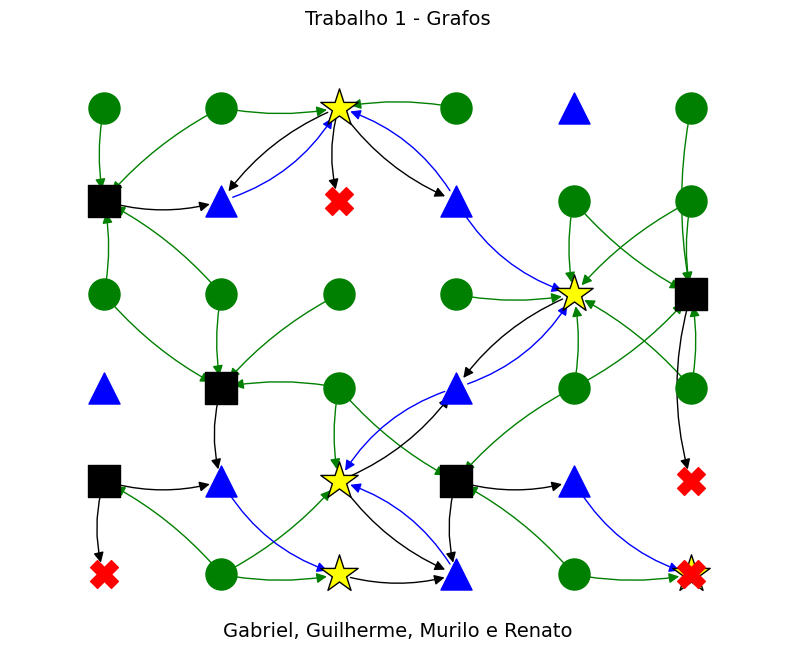

In [30]:
#plotagem do grafo
pos = nx.get_node_attributes(G, 'pos')
plt.figure(figsize=(10, 8))

#nós
nx.draw_networkx_nodes(G, pos, nodelist=circulos, node_shape='o', node_color='green', node_size=500)
nx.draw_networkx_nodes(G, pos, nodelist=quadrados, node_shape='s', node_color='black', node_size=500)
nx.draw_networkx_nodes(G, pos, nodelist=triangulos, node_shape='^', node_color='blue', node_size=500)

#nós finais (Estrela e X)
nx.draw_networkx_nodes(G, pos, nodelist=list(estrelas), node_shape='*', node_color='yellow', node_size=800, edgecolors='black')
nx.draw_networkx_nodes(G, pos, nodelist=list(interrompidos), node_shape='X', node_color='red', node_size=400)

#arestas
#o parâmetro connectionstyle='arc3, rad=0.2' curva a linha para evitar a sobreposição de arestas
nx.draw_networkx_edges(G, pos, edgelist=ar1, edge_color='green', arrows=True, arrowsize=15, connectionstyle='arc3, rad=0.1')
nx.draw_networkx_edges(G, pos, edgelist=ar2, edge_color='black', arrows=True, arrowsize=15, connectionstyle='arc3, rad=0.15')
nx.draw_networkx_edges(G, pos, edgelist=ar3, edge_color='blue', arrows=True, arrowsize=15, connectionstyle='arc3, rad=0.2')


plt.title("Trabalho 1 - Grafos", fontsize=14)
plt.text(0.5, 0.02, "Gabriel, Guilherme, Murilo e Renato", transform=plt.gca().transAxes, fontsize=14, ha='center')
plt.axis('off')
plt.margins(0.1)
plt.show()